# Why are Triphasic and Positive units fewer after filtering?

The filtered set contains far fewer Triphasic and Positive units than the
published composition: NarrTRI and MedTRI together fall from roughly twenty
percent to under three, while Wide rises from about a quarter to a half.

This notebook establishes whether that is a real property of the filtering or a
side effect of criteria that happen to select against these classes, and if so
which criterion is responsible.

The approach: classify **every** sorted unit, including the ones that were
removed, then ask which criterion each class fails. The classification needs the
mean waveform, so the unfiltered files must be read; the metrics dataframes on
their own carry no class label.

**The hypothesis worth testing first.** Triphasic and Positive units have the
lowest firing rates in the surviving set, 3.3 to 5.9 Hz against 11 to 12 Hz for
the Biphasic classes. Presence ratio counts the fraction of a hundred time bins
containing at least one spike, so a low-rate unit leaves more empty bins for
reasons that have nothing to do with isolation quality. If presence is the
criterion removing them, it is acting as a firing rate filter on exactly the
classes that carry the deep-layer part of the story.

In [1]:
import os
os.chdir('/CSNG/studekat/ripple_paper_clean_copy/code')

In [2]:
from functions_analysis import *
import pandas as pd, numpy as np, yaml, pickle, neo
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import zscore
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)

with open("/CSNG/studekat/ripple_paper_clean_copy/code/params_analysis.yml") as f:
    P = yaml.safe_load(f)

DF_FOLDER = '/CSNG/studekat/ripple_paper_clean_copy/dataframes'
CONDITIONS = {'RS':    ('L N F'.split(), P['data_folder']),
              'NATIM': ('N F'.split(),   P['natim_data_folder'])}
FINAL_CLASSES   = P['final_classes']
CLASS_COLORS    = P['colors_class']
WIDTH_INTERVALS = P['width_intervals']
PEAK_HEIGHT     = P['first_peak_height']
CLASS_DICT = {'DOWN_narrow_shallow':'NarrBI','DOWN_narrow_sharp':'NarrTRI',
              'DOWN_wide':'Wide','DOWN_medium_shallow':'MedBI',
              'DOWN_medium_sharp':'MedTRI','UP':'Pos'}
KEY = ['monkey','date','array','cell_name']

TYPE_REC = 'RS'          # switch to 'NATIM' and rerun
MONKEYS, DATA_FOLDER = CONDITIONS[TYPE_REC]
TARGET_CLASSES = ['DOWN_narrow_sharp','DOWN_medium_sharp','UP']   # the ones in question

## 1. Which thresholds are actually in force?

The written files record the rule that produced them. If they disagree with the
current `thresholds.pkl`, the files predate a threshold change and the write job
needs rerunning before anything below reflects the intended selection.

In [3]:
##### SPIKE FILE PATHS #####
#     spikes_KS4/{stem}_Array{N}_spikes_KS4.nix             earlier filtering
#     spikes_KS4/{stem}_Array{N}_spikes_KS4_unfiltered.nix  every sorted unit
#     spikes_filtered/{stem}_Array{N}_spikes_KS4_filtered.nix   this filtering

def recording_folder(monkey, date, type_rec, data_folder):
    """The recording directory, which differs between the two paradigms."""
    if type_rec == 'NATIM':
        return f'{data_folder}/macaque{monkey}_TVSD_{date}'
    return f'{data_folder}/macaque{monkey}_{type_rec}_{date}'


def file_stem(monkey, date, type_rec):
    """The filename prefix, again paradigm dependent."""
    if type_rec == 'NATIM':
        return f'macaque{monkey}_TVSD_{date}'
    return f'macaque{monkey}_{type_rec}_{date}'


def spike_path(monkey, date, array, type_rec, data_folder, kind='all'):
    """
    Path to one array's spike file.

    kind is 'all' for every sorted unit, 'good' for the earlier filtering, or
    'filtered' for the output of this filtering. Returns None if absent.
    """
    base = recording_folder(monkey, date, type_rec, data_folder)
    stem = file_stem(monkey, date, type_rec)
    sub, suf = {'all':      ('spikes_KS4',      'spikes_KS4_unfiltered'),
                'good':     ('spikes_KS4',      'spikes_KS4'),
                'filtered': ('spikes_filtered', 'spikes_KS4_filtered')}[kind]
    p = f'{base}/{sub}/{stem}_Array{array}_{suf}.nix'
    return p if os.path.isfile(p) else None


def all_units_path(monkey, date, array, type_rec, data_folder):
    return spike_path(monkey, date, array, type_rec, data_folder, kind='all')


def good_units_path(monkey, date, array, type_rec, data_folder):
    return spike_path(monkey, date, array, type_rec, data_folder, kind='good')


def filtered_path(monkey, date, array, type_rec, data_folder):
    return spike_path(monkey, date, array, type_rec, data_folder, kind='filtered')




## 2. Classify every sorted unit, kept and removed alike

The mean waveform is computed from the unfiltered files. This is the slow step;
set `MAX_RECORDINGS` for a first pass.

In [4]:
MAX_RECORDINGS = 3

rows, n_rec = [], 0
for m in MONKEYS:
    for date in P['dates'][m][TYPE_REC]:
        if MAX_RECORDINGS is not None and n_rec >= MAX_RECORDINGS:
            break
        found = False
        for array in range(1, 17):
            p = all_units_path(m, date, array, TYPE_REC, DATA_FOLDER)
            if not os.path.isfile(p):
                continue
            found = True
            try:
                io = neo.NixIO(p, 'ro'); blk = io.read_block()
                for st in blk.segments[0].spiketrains:
                    w = st.waveforms
                    if w is None or getattr(w, 'ndim', 0) < 2 or w.shape[0] < 5:
                        continue
                    wm = np.asarray(w.magnitude if hasattr(w, 'magnitude') else w,
                                    dtype=float)
                    if wm.ndim == 3:
                        wm = wm[:, 0, :]
                    rows.append({'monkey': m, 'date': date, 'array': array,
                                 'cell_name': st.annotations.get('nix_name', ''),
                                 'avg_wf': np.nanmean(wm, axis=0)})
                    del wm
                io.close(); del blk
            except Exception as e:
                print(f'   {m} {date} array {array}: {e}')
        if found:
            n_rec += 1
            print(f'   {m} {date}: {len(rows)} units so far', flush=True)

df_wf = pd.DataFrame(rows)
print(f'\n{len(df_wf)} units with a mean waveform, from {n_rec} recordings')

   L 20170725: 1798 units so far
   L 20170809: 3611 units so far
   L 20170810: 5370 units so far

5370 units with a mean waveform, from 3 recordings


In [5]:
with open(f'{DF_FOLDER}/filter_metrics_chosen/thresholds.pkl', 'rb') as f:
    TH = pickle.load(f)
CRITERIA = TH['criteria']
NAN_FAILS = TH.get('nan_fails', True)

for c, (d_, t) in CRITERIA.items():
    print(f'   {c:28s} keep {d_:5s} {t}')

   FR_computed                  keep above 1.0
   ann_line_noise_50Hz          keep below 0.6
   ann_line_noise_60Hz          keep below 0.6
   presence_ratio_computed      keep above 0.75
   ann_waveform_SNR             keep above 2.0
   wf_snr_computed              keep above 4.0
   viol_ratio_1p5ms             keep below 1.25
   coinc_ratio_worst            keep below 5.0


In [6]:
d = df_wf.copy()
d['avg_wf_zscored'] = [zscore(w) for w in d['avg_wf']]
d = aux_add_waveform_prop(d)
d['amp_wf_zscored'] = [np.max(w) - np.min(w) for w in d['avg_wf_zscored']]
d = aux_add_width_classes(d, width_intervals=WIDTH_INTERVALS)
d = aux_add_up_down_classes(d)
d = aux_add_final_classes(d, final_classes=FINAL_CLASSES,
                          peak_height_th=PEAK_HEIGHT)
d['first_peak_height'] = [first_peak_height_from_waveform(w)
                          for w in d['avg_wf_zscored']]

def load_all_metrics(type_rec, monkeys):
    dfs = []
    for m in monkeys:
        for date in P['dates'][m][type_rec]:
            p = f'{DF_FOLDER}/filter_metrics_{type_rec}/monkey{m}_all_arrays_date_{date}.pkl'
            try:
                with open(p,'rb') as f: dfs.append(pickle.load(f))
            except Exception:
                pass
    return pd.concat(dfs, ignore_index=True) if dfs else None

allm = load_all_metrics(TYPE_REC, MONKEYS)
metric_cols = [c for c in CRITERIA if c in allm.columns]
d = d.merge(allm[KEY + metric_cols + ['n_spikes','duration_s']],
            on=KEY, how='inner')

flags = pd.DataFrame(index=d.index)
for col, (direc, th) in CRITERIA.items():
    if col not in d.columns: continue
    v = d[col].replace([np.inf,-np.inf], np.nan)
    ok = (v <= th) if direc == 'below' else (v >= th)
    flags[col] = (ok & v.notna()) if NAN_FAILS else (ok | v.isna())
    d[f'pass_{col}'] = flags[col]
d['kept'] = flags.all(axis=1)
PASS = [f'pass_{c}' for c in flags.columns]

print(f'{len(d)} units matched to metrics, {int(d["kept"].sum())} pass '
      f'({100*d["kept"].mean():.1f}%)')

5370 units matched to metrics, 688 pass (12.8%)


## 3. Composition before and after

         before  after  pct_before  pct_after  retention
NarrBI      308     47         5.7        6.8      0.153
MedBI      1198    207        22.3       30.1      0.173
Wide        988    286        18.4       41.6      0.289
NarrTRI     152     44         2.8        6.4      0.289
MedTRI      254     88         4.7       12.8      0.346
Pos        2470     16        46.0        2.3      0.006

If retention differs markedly between classes, the filter is
class-selective and the composition change is its doing.


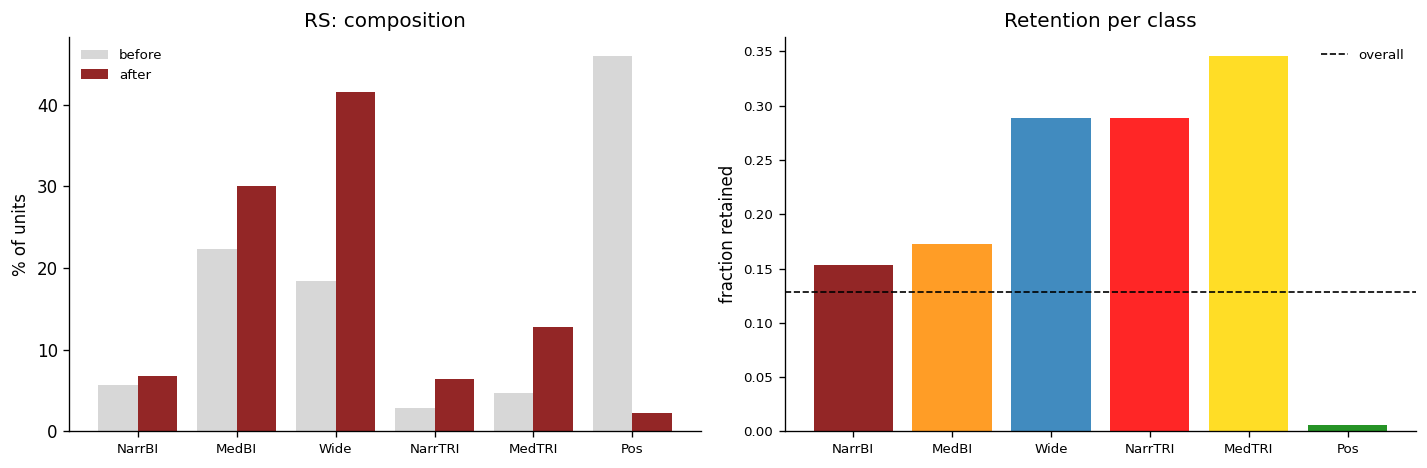

In [7]:
comp = pd.DataFrame({
    'before': d['final_class'].value_counts(),
    'after':  d.loc[d['kept'], 'final_class'].value_counts()}).fillna(0).astype(int)
comp = comp.reindex([c for c in FINAL_CLASSES if c in comp.index])
comp.index = [CLASS_DICT.get(i, i) for i in comp.index]
comp['pct_before'] = (100*comp['before']/comp['before'].sum()).round(1)
comp['pct_after']  = (100*comp['after']/max(comp['after'].sum(),1)).round(1)
comp['retention']  = (comp['after']/comp['before']).round(3)
print(comp.to_string())
print()
print('If retention differs markedly between classes, the filter is')
print('class-selective and the composition change is its doing.')

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=120)
x = np.arange(len(comp))
axes[0].bar(x-0.2, comp['pct_before'], width=0.4, color='lightgray',
            alpha=0.9, label='before')
axes[0].bar(x+0.2, comp['pct_after'], width=0.4, color='maroon',
            alpha=0.85, label='after')
axes[0].set_xticks(x); axes[0].set_xticklabels(comp.index, fontsize=8)
axes[0].set_ylabel('% of units'); axes[0].legend(fontsize=8, frameon=False)
axes[0].set_title(f'{TYPE_REC}: composition')

cols = [CLASS_COLORS.get(c, 'gray') for c in FINAL_CLASSES if CLASS_DICT.get(c) in comp.index]
axes[1].bar(comp.index, comp['retention'], color=cols, alpha=0.85)
axes[1].axhline(d['kept'].mean(), color='k', ls='--', lw=1, label='overall')
axes[1].set_ylabel('fraction retained'); axes[1].legend(fontsize=8, frameon=False)
axes[1].set_title('Retention per class'); axes[1].tick_params(labelsize=8)
for ax in axes:
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

## 4. Which criterion removes each class?

Two views. The failure rate is the fraction of a class failing each criterion,
and a class can fail several at once. The sole reason counts units that fail one
criterion and pass all the others, which identifies the criterion actually
responsible.

FAILURE RATE, fraction of the class failing each criterion
                         NarrBI  MedBI   Wide  NarrTRI  MedTRI    Pos
FR_computed               0.023  0.006  0.053    0.007   0.004  0.002
ann_line_noise_50Hz       0.010  0.003  0.008    0.000   0.000  0.006
ann_line_noise_60Hz       0.045  0.085  0.047    0.013   0.024  0.009
presence_ratio_computed   0.003  0.000  0.019    0.000   0.000  0.000
ann_waveform_SNR          0.003  0.003  0.009    0.007   0.051  0.911
wf_snr_computed           0.416  0.531  0.516    0.026   0.213  0.692
viol_ratio_1p5ms          0.718  0.688  0.321    0.632   0.528  0.551
coinc_ratio_worst         0.273  0.193  0.173    0.105   0.091  0.112

SOLE REASON, fails this criterion and passes all others
                         NarrBI  MedBI  Wide  NarrTRI  MedTRI   Pos
n_class                     308   1198   988      152     254  2470
n_removed                   261    991   702      108     166  2454
FR_computed                   1      0    16      

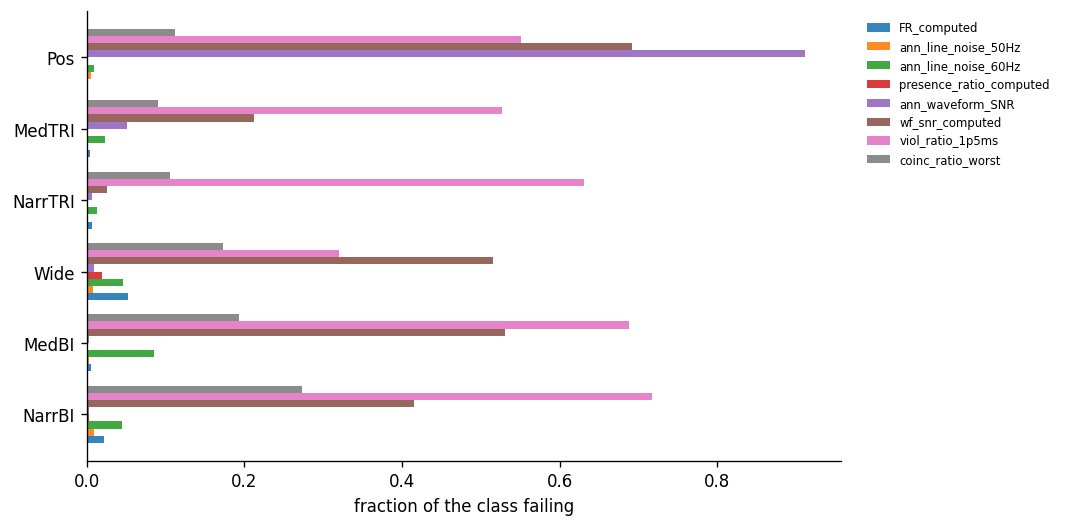

In [8]:
present = [c for c in FINAL_CLASSES if (d['final_class'] == c).any()]

fail = pd.DataFrame({
    CLASS_DICT[cl]: (~d.loc[d['final_class'] == cl, PASS]).mean()
    for cl in present})
fail.index = [i.replace('pass_','') for i in fail.index]
print('FAILURE RATE, fraction of the class failing each criterion')
print(fail.round(3).to_string())
print()

sole = {}
for cl in present:
    sub = d[d['final_class'] == cl]
    col = {'n_class': len(sub), 'n_removed': int((~sub['kept']).sum())}
    for c in PASS:
        others = sub[[x for x in PASS if x != c]].all(axis=1)
        col[c.replace('pass_','')] = int((others & ~sub[c]).sum())
    sole[CLASS_DICT[cl]] = col
df_sole = pd.DataFrame(sole)
print('SOLE REASON, fails this criterion and passes all others')
print(df_sole.to_string())
print()
print('A criterion with a high sole count for a class is the one removing it.')

fig, ax = plt.subplots(figsize=(9, 4.5), dpi=120)
fail.T.plot.barh(ax=ax, alpha=0.9, width=0.8)
ax.set_xlabel('fraction of the class failing')
ax.legend(fontsize=7, frameon=False, bbox_to_anchor=(1.02, 1))
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

## 5. The metric values behind those failures

Where a class sits relative to each threshold, so the reason is visible rather
than inferred.

MEDIAN METRIC VALUE BY CLASS
         FR_computed  ann_line_noise_50Hz  ann_line_noise_60Hz  presence_ratio_computed  ann_waveform_SNR  wf_snr_computed  viol_ratio_1p5ms  coinc_ratio_worst
NarrBI       58.9638               0.3758               0.4746                      1.0            6.2309           4.1385            2.2927             3.6620
MedBI        43.1054               0.4040               0.4993                      1.0            4.2982           3.9778            1.8820             2.9178
Wide         26.4983               0.3255               0.4011                      1.0            3.1518           3.9804            0.8510             2.1465
NarrTRI      11.4492               0.1755               0.1960                      1.0            3.7879           5.0566            1.3785             2.0764
MedTRI       12.6697               0.1901               0.2219                      1.0            3.3541           4.3627            1.3236             2.0421
Pos        

/tmp/ipykernel_55018/3320895745.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[CLASS_DICT[c] for c in present],
/tmp/ipykernel_55018/3320895745.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[CLASS_DICT[c] for c in present],
/tmp/ipykernel_55018/3320895745.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[CLASS_DICT[c] for c in present],
/tmp/ipykernel_55018/3320895745.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old nam

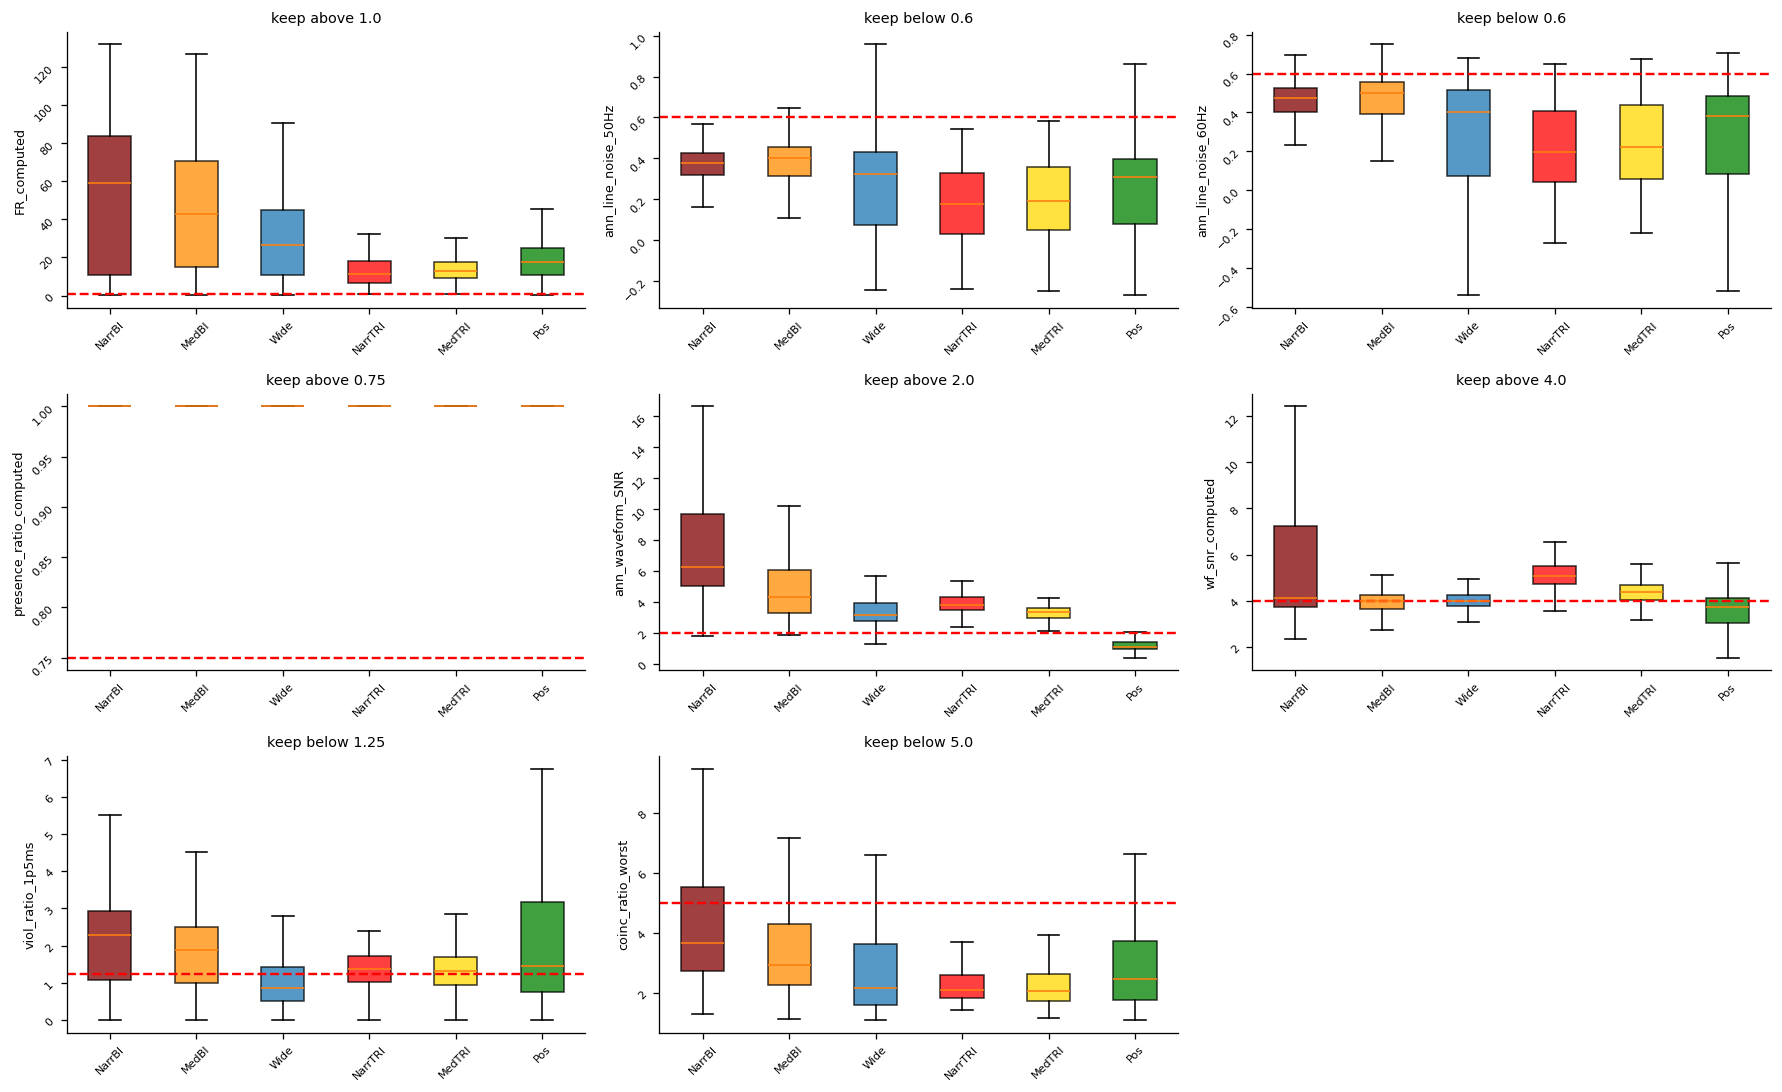

In [9]:
med = d.groupby('final_class')[metric_cols].median()
med = med.reindex([c for c in FINAL_CLASSES if c in med.index])
med.index = [CLASS_DICT.get(i, i) for i in med.index]
print('MEDIAN METRIC VALUE BY CLASS')
print(med.round(4).to_string())
print()
print('thresholds:')
for c, (d_, t) in CRITERIA.items():
    print(f'   {c:28s} keep {d_:5s} {t}')

n = len(metric_cols); ncol = 3; nrow = int(np.ceil(n/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5.2*ncol, 3.2*nrow), dpi=115)
axes = np.atleast_1d(axes).ravel()
for ax, col in zip(axes, metric_cols):
    direc, th = CRITERIA[col]
    data = [d.loc[d['final_class'] == cl, col]
            .replace([np.inf,-np.inf], np.nan).dropna().values
            for cl in present]
    bp = ax.boxplot(data, labels=[CLASS_DICT[c] for c in present],
                    patch_artist=True, showfliers=False)
    for patch, cl in zip(bp['boxes'], present):
        patch.set_facecolor(CLASS_COLORS[cl]); patch.set_alpha(0.75)
    ax.axhline(th, color='r', ls='--', lw=1.5)
    ax.set_ylabel(col, fontsize=8)
    ax.set_title(f'keep {direc} {th}', fontsize=9)
    ax.tick_params(labelsize=7, rotation=45)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
for ax in axes[n:]:
    ax.axis('off')
plt.tight_layout(); plt.show()

## 6. Is the responsible criterion acting as a firing rate filter?

Presence ratio counts the fraction of a hundred time bins containing at least
one spike. A unit at 3 Hz over a twenty minute recording leaves empty bins for
arithmetic reasons alone, with no bearing on isolation quality. If the classes
being removed are simply the slower ones, the criterion is selecting on rate.

firing rate and presence by class:
            n      FR  presence  n_spikes
NarrBI    308  58.964       1.0   78899.5
MedBI    1198  43.105       1.0   57282.5
Wide      988  26.498       1.0   35286.5
NarrTRI   152  11.449       1.0   15381.5
MedTRI    254  12.670       1.0   16791.0
Pos      2470  17.386       1.0   23040.0

presence vs firing rate: Spearman rho +0.222, p 4.25e-61
   A strong positive value means presence is largely a rate measure.



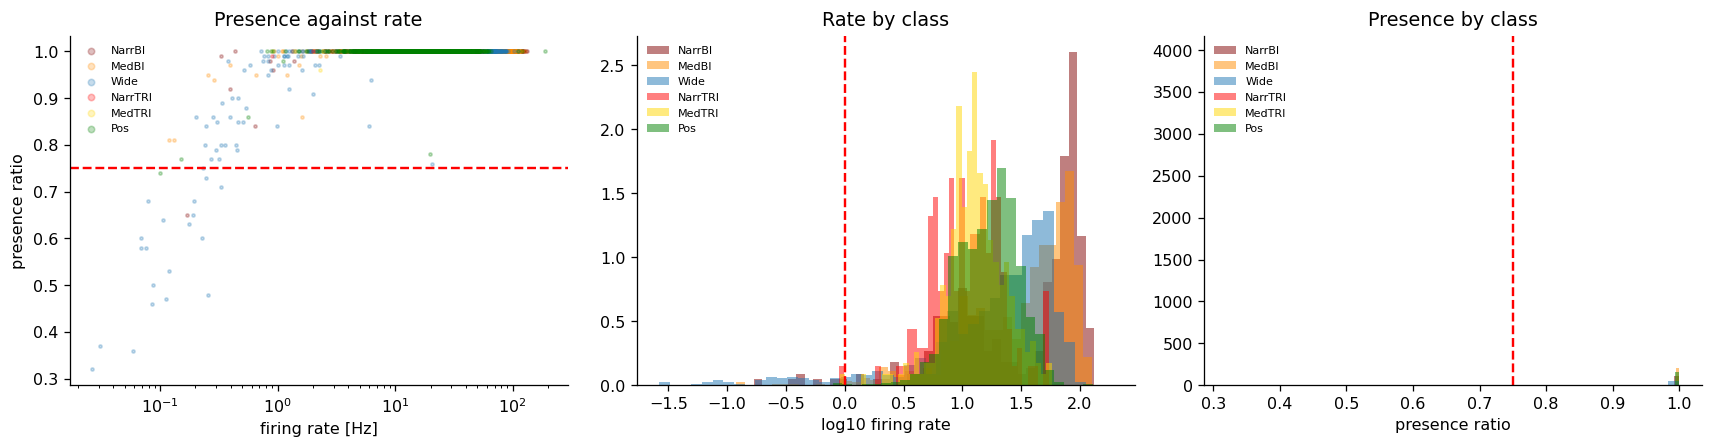

In [10]:
print('firing rate and presence by class:')
rate_tab = d.groupby('final_class').agg(
    n=('cell_name','size'),
    FR=('FR_computed','median') if 'FR_computed' in d.columns else ('n_spikes','median'),
    presence=('presence_ratio_computed','median'),
    n_spikes=('n_spikes','median')).reindex(
    [c for c in FINAL_CLASSES if c in d['final_class'].unique()])
rate_tab.index = [CLASS_DICT.get(i, i) for i in rate_tab.index]
print(rate_tab.round(3).to_string())
print()

if 'presence_ratio_computed' in d.columns and 'FR_computed' in d.columns:
    v = d[['presence_ratio_computed','FR_computed']].replace(
        [np.inf,-np.inf], np.nan).dropna()
    r = stats.spearmanr(v['presence_ratio_computed'], v['FR_computed'])
    print(f'presence vs firing rate: Spearman rho {r.statistic:+.3f}, '
          f'p {r.pvalue:.2e}')
    print('   A strong positive value means presence is largely a rate measure.')
    print()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=115)
    ax = axes[0]
    for cl in present:
        sub = d[d['final_class'] == cl]
        ax.scatter(sub['FR_computed'], sub['presence_ratio_computed'], s=4,
                   alpha=0.25, color=CLASS_COLORS[cl], label=CLASS_DICT[cl])
    ax.axhline(CRITERIA['presence_ratio_computed'][1], color='r', ls='--', lw=1.5)
    ax.set_xscale('log'); ax.set_xlabel('firing rate [Hz]')
    ax.set_ylabel('presence ratio'); ax.legend(fontsize=7, frameon=False, markerscale=2)
    ax.set_title('Presence against rate')

    ax = axes[1]
    for cl in present:
        v2 = d.loc[d['final_class'] == cl, 'FR_computed'].dropna()
        if len(v2) > 10:
            ax.hist(np.log10(np.clip(v2, 0.01, None)), bins=40, alpha=0.5,
                    density=True, color=CLASS_COLORS[cl], label=CLASS_DICT[cl])
    ax.axvline(np.log10(CRITERIA.get('FR_computed', ('above',1.0))[1]),
               color='r', ls='--', lw=1.5)
    ax.set_xlabel('log10 firing rate'); ax.legend(fontsize=7, frameon=False)
    ax.set_title('Rate by class')

    ax = axes[2]
    for cl in present:
        v2 = d.loc[d['final_class'] == cl, 'presence_ratio_computed'].dropna()
        if len(v2) > 10:
            ax.hist(v2, bins=40, alpha=0.5, density=True,
                    color=CLASS_COLORS[cl], label=CLASS_DICT[cl])
    ax.axvline(CRITERIA['presence_ratio_computed'][1], color='r', ls='--', lw=1.5)
    ax.set_xlabel('presence ratio'); ax.legend(fontsize=7, frameon=False)
    ax.set_title('Presence by class')
    for a_ in axes:
        a_.spines['top'].set_visible(False); a_.spines['right'].set_visible(False)
    plt.tight_layout(); plt.show()

### 6.1 Matched comparison

If the classes differ in retention only because they differ in firing rate, then
matching on rate should remove the difference. If retention still differs after
matching, something about the classes themselves is being selected against.

In [11]:
if 'FR_computed' in d.columns:
    d['fr_bin'] = pd.qcut(d['FR_computed'].rank(method='first'), 10,
                          labels=False, duplicates='drop')
    rows = []
    for cl in present:
        sub = d[d['final_class'] == cl]
        raw = sub['kept'].mean()
        # retention this class would have at the rate distribution of all units
        adj, wtot = 0.0, 0.0
        for b, g in sub.groupby('fr_bin'):
            w = (d['fr_bin'] == b).mean()
            adj += w * g['kept'].mean(); wtot += w
        rows.append({'class': CLASS_DICT[cl], 'n': len(sub),
                     'median_FR': round(sub['FR_computed'].median(), 2),
                     'retention_raw': round(raw, 3),
                     'retention_rate_matched': round(adj/wtot, 3) if wtot else np.nan})
    df_adj = pd.DataFrame(rows)
    df_adj['difference'] = (df_adj['retention_rate_matched']
                            - df_adj['retention_raw']).round(3)
    print(df_adj.to_string(index=False))
    print()
    print('retention_rate_matched is what each class would retain if its firing')
    print('rates matched the whole population. Where it rises toward the overall')
    print('level, the loss was a rate effect.')

  class    n  median_FR  retention_raw  retention_rate_matched  difference
 NarrBI  308      58.96          0.153                   0.265       0.112
  MedBI 1198      43.11          0.173                   0.281       0.108
   Wide  988      26.50          0.289                   0.316       0.027
NarrTRI  152      11.45          0.289                   0.179      -0.110
 MedTRI  254      12.67          0.346                   0.271      -0.075
    Pos 2470      17.39          0.006                   0.007       0.001

retention_rate_matched is what each class would retain if its firing
rates matched the whole population. Where it rises toward the overall
level, the loss was a rate effect.


## 7. Was the same class also scarce before any filtering?

The published composition came from the pipeline's own good-units selection,
which applied its own criteria. Part of the change may predate this filtering
entirely, so the three compositions are compared: every sorted unit, the
pipeline's selection, and the new one.

COUNTS
         all sorted  pipeline good_units  new filtering
NarrBI          308                    0             47
MedBI          1198                    0            207
Wide            988                    0            286
NarrTRI         152                    0             44
MedTRI          254                    0             88
Pos            2470                    0             16

PERCENTAGES
         all sorted  pipeline good_units  new filtering
NarrBI          5.7                  NaN            6.8
MedBI          22.3                  NaN           30.1
Wide           18.4                  NaN           41.6
NarrTRI         2.8                  NaN            6.4
MedTRI          4.7                  NaN           12.8
Pos            46.0                  NaN            2.3

Published composition for comparison: NarrBI 15.6, MedBI 40.9, Wide 22.5,
NarrTRI 9.4, MedTRI 10.3, Pos 1.3 percent.


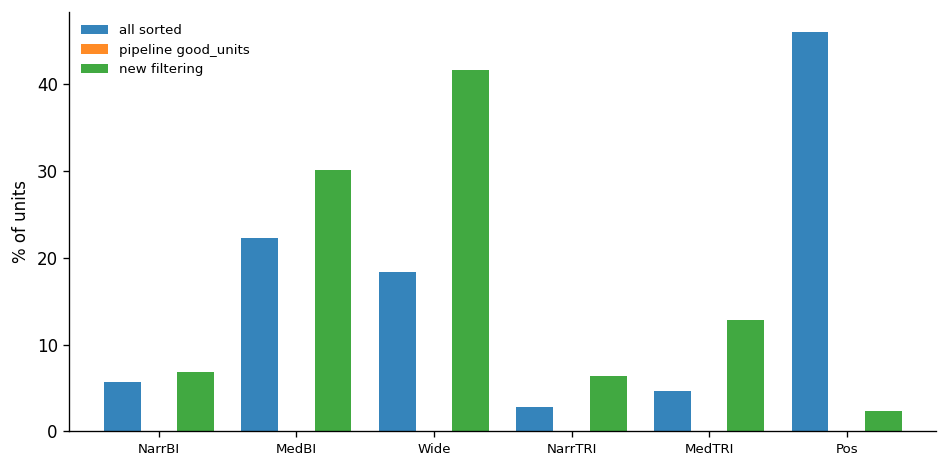

In [12]:
def names_in_good_units(monkey, date, type_rec, data_folder):
    stem = (f'macaque{monkey}_TVSD_{date}' if type_rec == 'NATIM'
            else f'macaque{monkey}_{type_rec}_{date}')
    out = set()
    for array in range(1, 17):
        p = f'{data_folder}/{stem}/spikes/{stem}_Array{array}_spikes_good_units.nix'
        if not os.path.isfile(p): continue
        try:
            io = neo.NixIO(p, 'ro'); blk = io.read_block()
            for st in blk.segments[0].spiketrains:
                out.add((array, st.annotations.get('nix_name', None)))
            io.close()
        except Exception:
            pass
    return out

good = set()
for m in MONKEYS:
    for date in P['dates'][m][TYPE_REC]:
        for k in names_in_good_units(m, date, TYPE_REC, DATA_FOLDER):
            good.add((m, date) + k)
d['keep_old'] = [(r.monkey, r.date, int(r.array), r.cell_name) in good
                 for r in d.itertuples()]

three = pd.DataFrame({
    'all sorted': d['final_class'].value_counts(),
    'pipeline good_units': d.loc[d['keep_old'], 'final_class'].value_counts(),
    'new filtering': d.loc[d['kept'], 'final_class'].value_counts()}).fillna(0).astype(int)
three = three.reindex([c for c in FINAL_CLASSES if c in three.index])
three.index = [CLASS_DICT.get(i, i) for i in three.index]
pct = (100*three/three.sum()).round(1)
print('COUNTS'); print(three.to_string())
print(); print('PERCENTAGES'); print(pct.to_string())
print()
print('Published composition for comparison: NarrBI 15.6, MedBI 40.9, Wide 22.5,')
print('NarrTRI 9.4, MedTRI 10.3, Pos 1.3 percent.')

fig, ax = plt.subplots(figsize=(8, 4), dpi=120)
pct.plot.bar(ax=ax, alpha=0.9, width=0.8)
ax.set_ylabel('% of units'); ax.legend(fontsize=8, frameon=False)
ax.tick_params(axis='x', labelsize=8, rotation=0)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

## 8. What would relaxing the responsible criterion recover?

Retention per class at a range of thresholds for whichever criterion the sole
reason table implicated.

In [13]:
RELAX = 'presence_ratio_computed'      # <-- set from section 4
SWEEP = [0.3, 0.5, 0.6, 0.75, 0.9]

if RELAX in d.columns:
    direc = CRITERIA[RELAX][0]
    others = [c for c in PASS if c != f'pass_{RELAX}']
    base = d[others].all(axis=1)
    rows = []
    for th in SWEEP:
        v = d[RELAX].replace([np.inf,-np.inf], np.nan)
        ok = ((v <= th) if direc == 'below' else (v >= th)) & v.notna()
        keep = base & ok
        r = {'threshold': th, 'total_kept': int(keep.sum()),
             'pct_total': round(100*keep.mean(), 1)}
        for cl in present:
            m = d['final_class'] == cl
            r[CLASS_DICT[cl]] = int((keep & m).sum())
        rows.append(r)
    df_relax = pd.DataFrame(rows)
    print(f'{RELAX}, keep {direc}:')
    print(df_relax.to_string(index=False))
    print()
    pcts = df_relax[[CLASS_DICT[c] for c in present]].div(
        df_relax['total_kept'], axis=0).mul(100).round(1)
    pcts.insert(0, 'threshold', df_relax['threshold'])
    print('resulting composition, percent:')
    print(pcts.to_string(index=False))

presence_ratio_computed, keep above:
 threshold  total_kept  pct_total  NarrBI  MedBI  Wide  NarrTRI  MedTRI  Pos
      0.30         688       12.8      47    207   286       44      88   16
      0.50         688       12.8      47    207   286       44      88   16
      0.60         688       12.8      47    207   286       44      88   16
      0.75         688       12.8      47    207   286       44      88   16
      0.90         687       12.8      47    207   285       44      88   16

resulting composition, percent:
 threshold  NarrBI  MedBI  Wide  NarrTRI  MedTRI  Pos
      0.30     6.8   30.1  41.6      6.4    12.8  2.3
      0.50     6.8   30.1  41.6      6.4    12.8  2.3
      0.60     6.8   30.1  41.6      6.4    12.8  2.3
      0.75     6.8   30.1  41.6      6.4    12.8  2.3
      0.90     6.8   30.1  41.5      6.4    12.8  2.3


## 9. Export

In [14]:
OUT = f'{DF_FOLDER}/filtered_validation'
ensure_dir_exists(OUT)
cols = [c for c in d.columns if c not in ('avg_wf','avg_wf_zscored')]
d[cols].to_csv(f'{OUT}/class_vs_criteria_{TYPE_REC}.csv', index=False)
fail.to_csv(f'{OUT}/failure_rate_by_class_{TYPE_REC}.csv')
df_sole.to_csv(f'{OUT}/sole_reason_by_class_{TYPE_REC}.csv')
print('saved to', OUT)

saved to /CSNG/studekat/ripple_paper_clean_copy/dataframes/filtered_validation


## How to read this

**Section 1 is a gate.** If the thresholds recorded in the written files differ
from `thresholds.pkl`, the files predate a change and the write job must be
rerun before anything here reflects the intended selection.

**Section 4 gives the answer.** The sole reason table names the criterion
responsible for each class. A criterion that is never the sole reason is
redundant; one that dominates a class is what removed it.

**Section 6 asks whether that criterion is legitimate.** Presence ratio counts
bins containing at least one spike, so it necessarily falls with firing rate. If
Triphasic and Positive units are removed simply for being slower, the criterion
is selecting on rate rather than on isolation, and these are the classes that
carry the deep-layer part of the analysis.

**Section 6.1 separates the two.** Retention reweighted to a common rate
distribution shows what each class would retain if rate were held constant. A
large rise means the loss was a rate effect.

**Section 7 puts the change in context.** Part of the compositional shift may
predate this filtering, since the published figure came from the pipeline's own
selection. Comparing all three tells you how much is new.

**Section 8 is the remedy, if one is wanted.** It shows what each threshold
would retain per class, so a value can be chosen with the compositional
consequence visible rather than discovered afterwards.